In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv('cleaned_cognitive_fatigue_dataset.csv')
print(df.shape)

(98535, 12)


In [4]:
df.head()

,screen_time,sleep_hours,stress_level,wellness_index,sleep_quality,fatigue_score,digital_balance,screen_time_category,physical_activity,caffeine_intake,work_hours,mood
0,10.79,6.63,9.3,9.3,Moderate,6.710,0.562341,High,1,1,6,Exhausted
1,7.40,8.05,5.7,56.2,Good,3.630,0.958333,Moderate,4,1,9,Normal
2,9.78,6.48,9.1,3.6,Moderate,6.256,0.601113,High,2,1,5,Exhausted
3,11.13,6.89,10.0,0.0,Moderate,7.074,0.568013,High,3,0,9,Exhausted
4,13.22,5.79,10.0,0.0,Moderate,8.130,0.407173,High,4,1,8,Exhausted


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98535 entries, 0 to 98534
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   screen_time           98535 non-null  float64
 1   sleep_hours           98535 non-null  float64
 2   stress_level          98535 non-null  float64
 3   wellness_index        98535 non-null  float64
 4   sleep_quality         98535 non-null  object 
 5   fatigue_score         98535 non-null  float64
 6   digital_balance       98535 non-null  float64
 7   screen_time_category  98535 non-null  object 
 8   physical_activity     98535 non-null  int64  
 9   caffeine_intake       98535 non-null  int64  
 10  work_hours            98535 non-null  int64  
 11  mood                  98535 non-null  object 
dtypes: float64(6), int64(3), object(3)
memory usage: 9.0+ MB


In [6]:
df.dtypes

screen_time             float64
sleep_hours             float64
stress_level            float64
wellness_index          float64
sleep_quality            object
fatigue_score           float64
digital_balance         float64
screen_time_category     object
physical_activity         int64
caffeine_intake           int64
work_hours                int64
mood                     object
dtype: object

In [7]:
df.isnull().sum()

screen_time             0
sleep_hours             0
stress_level            0
wellness_index          0
sleep_quality           0
fatigue_score           0
digital_balance         0
screen_time_category    0
physical_activity       0
caffeine_intake         0
work_hours              0
mood                    0
dtype: int64

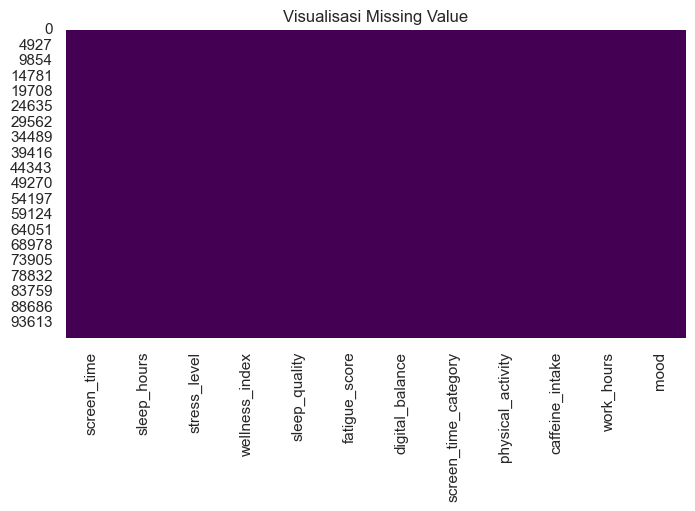

In [8]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualisasi Missing Value')
plt.show()

In [9]:
df.describe()

,screen_time,sleep_hours,stress_level,wellness_index,fatigue_score,digital_balance,physical_activity,caffeine_intake,work_hours
count,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000
mean,6.029388,0.594462,0.608154,0.960015,2.536124,0.092364,1.996854,1.502502,7.988156
std,2.002610,0.463438,0.548868,1.798835,0.875072,0.068790,1.410711,1.117923,2.583584
min,1.000000,0.000000,0.000000,0.000000,-1.070000,0.000000,0.000000,0.000000,4.000000
25%,4.700000,0.428571,0.444444,0.750000,1.947937,0.057915,1.000000,1.000000,6.000000
50%,6.000000,0.571429,0.555556,1.000000,2.525397,0.081395,2.000000,2.000000,8.000000
75%,7.400000,0.714286,0.777778,1.000000,3.106984,0.111380,3.000000,3.000000,10.000000
max,19.170000,9.740000,10.000000,97.000000,10.330000,3.630000,4.000000,3.000000,12.000000


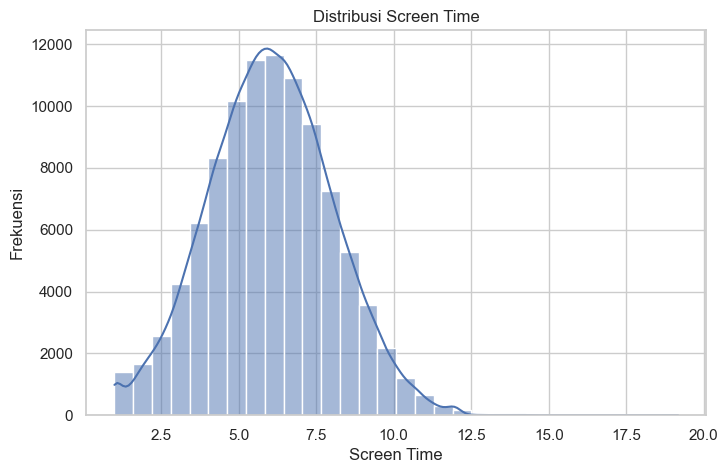

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['screen_time'], bins=30, kde=True)
plt.title('Distribusi Screen Time')
plt.xlabel('Screen Time')
plt.ylabel('Frekuensi')
plt.show()

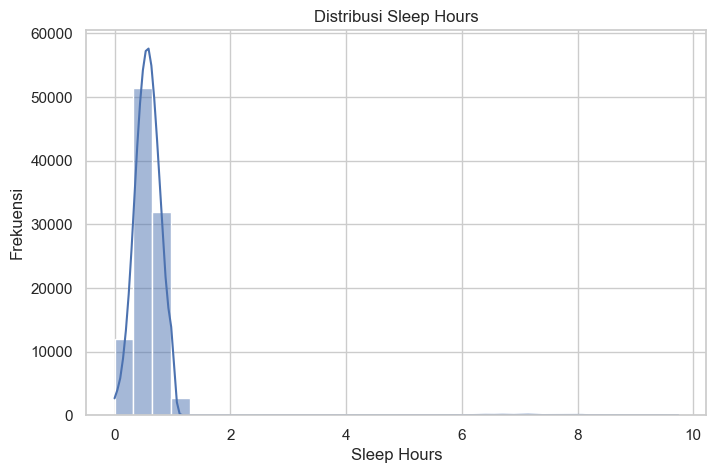

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_hours'], bins=30, kde=True)
plt.title('Distribusi Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frekuensi')
plt.show()

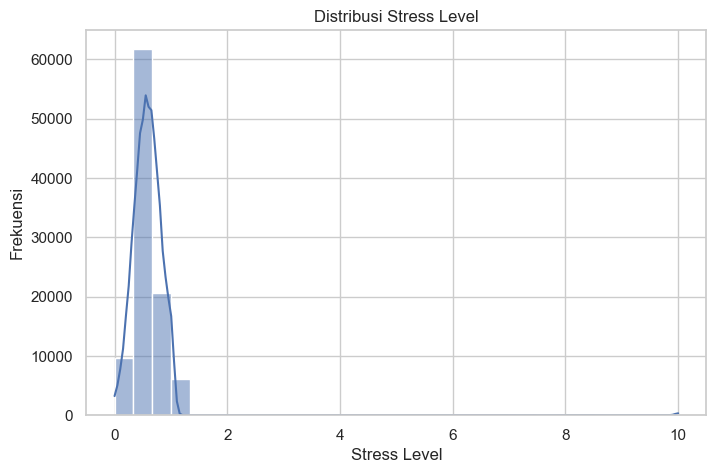

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['stress_level'], bins=30, kde=True)
plt.title('Distribusi Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')
plt.show()

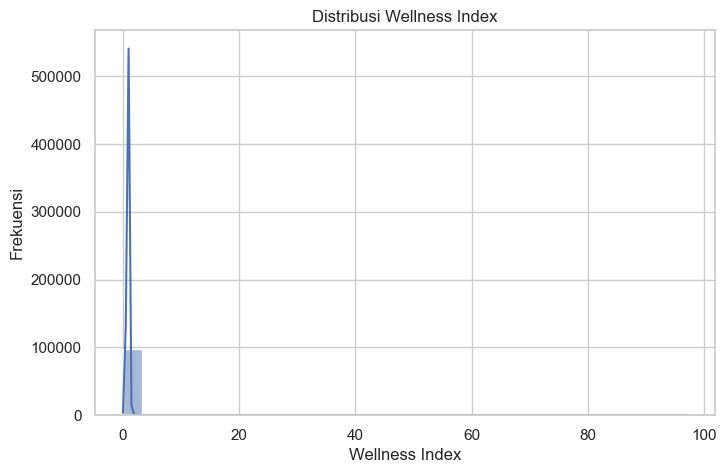

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['wellness_index'], bins=30, kde=True)
plt.title('Distribusi Wellness Index')
plt.xlabel('Wellness Index')
plt.ylabel('Frekuensi')
plt.show()

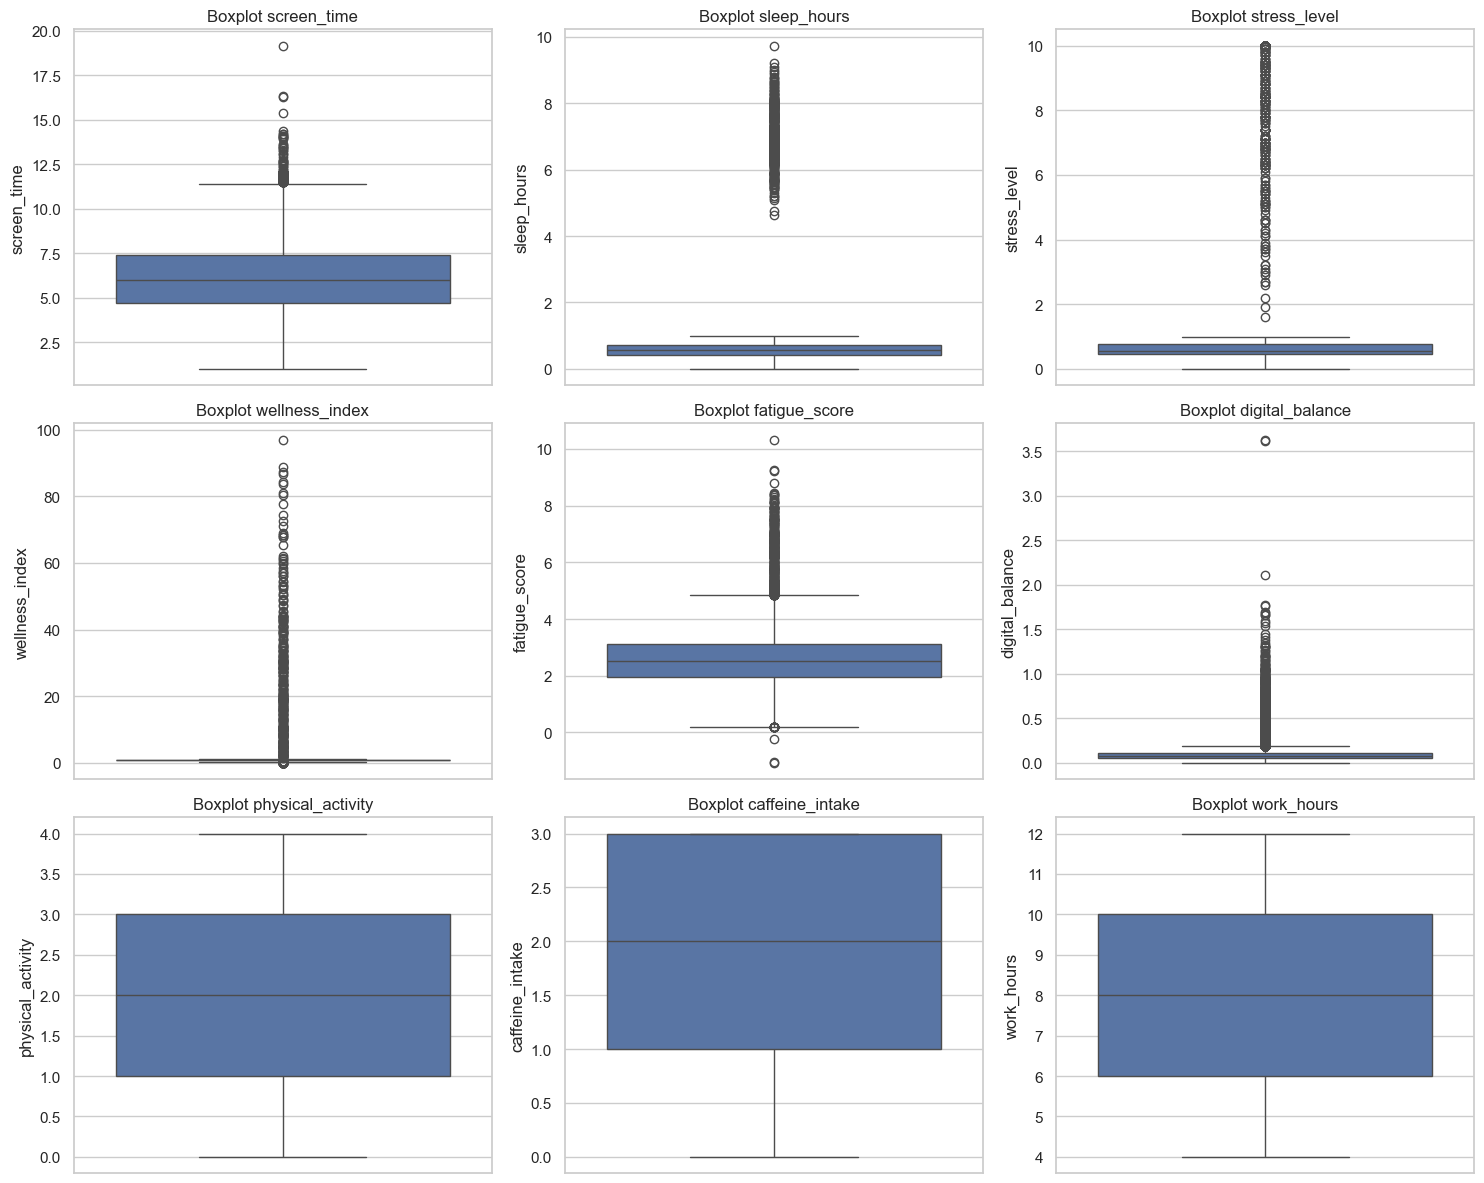

In [15]:
numeric_cols = df.select_dtypes(include='number').columns
n_numeric = len(numeric_cols)
cols = 3
rows = int(np.ceil(n_numeric / cols))

plt.figure(figsize=(cols * 5, rows * 4))

for i, column in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot {column}')

plt.tight_layout()
plt.show()

In [17]:
print("Jumlah Outlier Setiap Kolom:\n")

numeric_cols = df.select_dtypes(include='number').columns
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f'{column}: {len(outlier)} outlier')

Jumlah Outlier Setiap Kolom:

screen_time: 358 outlier
sleep_hours: 400 outlier
stress_level: 397 outlier
wellness_index: 792 outlier
fatigue_score: 580 outlier
digital_balance: 3969 outlier
physical_activity: 0 outlier
caffeine_intake: 0 outlier
work_hours: 0 outlier



Matriks Korelasi:
                   screen_time  sleep_hours  stress_level  wellness_index  \
screen_time           1.000000     0.082649      0.299428       -0.000774   
sleep_hours           0.082649     1.000000      0.632896        0.683415   
stress_level          0.299428     0.632896      1.000000        0.419641   
wellness_index       -0.000774     0.683415      0.419641        1.000000   
fatigue_score         0.981773     0.128524      0.457951        0.032188   
digital_balance      -0.397812     0.787914      0.263755        0.625395   
physical_activity     0.003157     0.000774      0.000426       -0.000200   
caffeine_intake       0.005171    -0.000489      0.003230        0.003728   
work_hours           -0.003554    -0.003111     -0.004206        0.000723   

                   fatigue_score  digital_balance  physical_activity  \
screen_time             0.981773        -0.397812           0.003157   
sleep_hours             0.128524         0.787914           0.0007

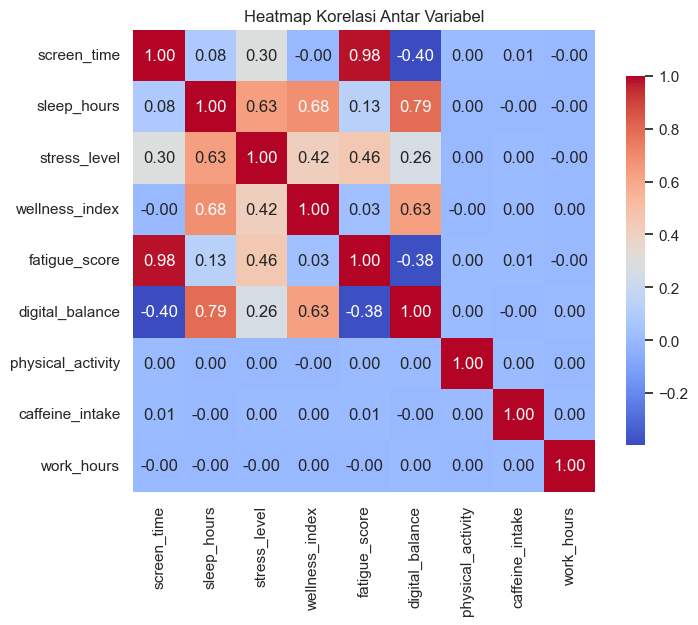

In [19]:
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

print("\nMatriks Korelasi:")
print(correlation)

# Heatmap korelasi
plt.figure(figsize=(8,6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

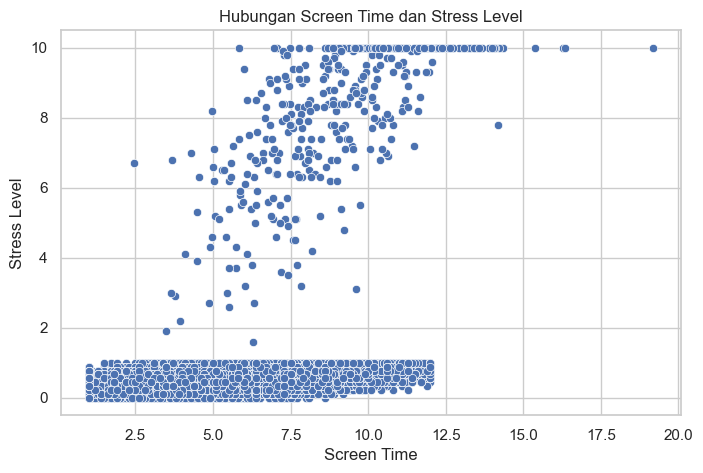

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='screen_time',
                y='stress_level',
                data=df)

plt.title('Hubungan Screen Time dan Stress Level')
plt.xlabel('Screen Time')
plt.ylabel('Stress Level')
plt.show()

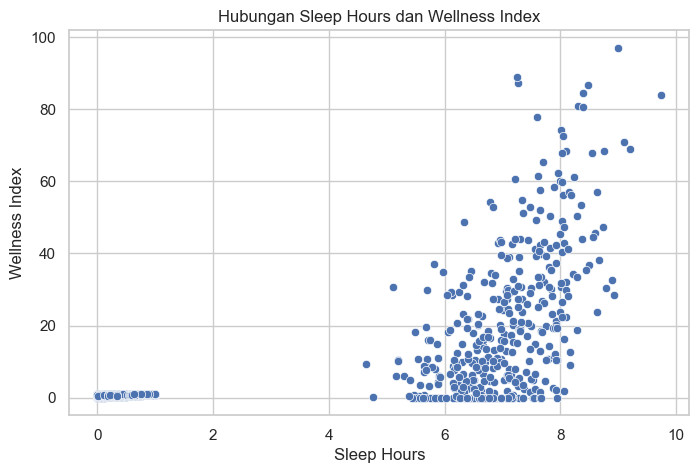

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sleep_hours',
                y='wellness_index',
                data=df)

plt.title('Hubungan Sleep Hours dan Wellness Index')
plt.xlabel('Sleep Hours')
plt.ylabel('Wellness Index')
plt.show()

In [22]:
for column in df.columns:
    print(f"\nJumlah nilai unik pada {column}:")
    print(df[column].nunique())


Jumlah nilai unik pada screen_time:
398

Jumlah nilai unik pada sleep_hours:
301

Jumlah nilai unik pada stress_level:
82

Jumlah nilai unik pada wellness_index:
270

Jumlah nilai unik pada sleep_quality:
3

Jumlah nilai unik pada fatigue_score:
15247

Jumlah nilai unik pada digital_balance:
5186

Jumlah nilai unik pada screen_time_category:
3

Jumlah nilai unik pada physical_activity:
5

Jumlah nilai unik pada caffeine_intake:
4

Jumlah nilai unik pada work_hours:
9

Jumlah nilai unik pada mood:
3


In [23]:
df.duplicated().sum()

np.int64(920)

In [24]:
for column in df.columns:
    print(f'{column}')
    print(f'Minimum : {df[column].min()}')
    print(f'Maksimum: {df[column].max()}')
    print('-'*30)

screen_time
Minimum : 1.0
Maksimum: 19.17
------------------------------
sleep_hours
Minimum : 0.0
Maksimum: 9.74
------------------------------
stress_level
Minimum : 0.0
Maksimum: 10.0
------------------------------
wellness_index
Minimum : 0.0
Maksimum: 97.0
------------------------------
sleep_quality
Minimum : Good
Maksimum: Poor
------------------------------
fatigue_score
Minimum : -1.07
Maksimum: 10.330000000000002
------------------------------
digital_balance
Minimum : 0.0
Maksimum: 3.63
------------------------------
screen_time_category
Minimum : High
Maksimum: Moderate
------------------------------
physical_activity
Minimum : 0
Maksimum: 4
------------------------------
caffeine_intake
Minimum : 0
Maksimum: 3
------------------------------
work_hours
Minimum : 4
Maksimum: 12
------------------------------
mood
Minimum : Exhausted
Maksimum: Relaxed
------------------------------


In [26]:
numeric_df = df.select_dtypes(include='number')
mean_values = numeric_df.mean()

print("\nRata-rata Setiap Variabel:")
print(mean_values)


Rata-rata Setiap Variabel:
screen_time          6.029388
sleep_hours          0.594462
stress_level         0.608154
wellness_index       0.960015
fatigue_score        2.536124
digital_balance      0.092364
physical_activity    1.996854
caffeine_intake      1.502502
work_hours           7.988156
dtype: float64


In [27]:
numeric_df = df.select_dtypes(include='number')
median_values = numeric_df.median()

print("\nMedian Setiap Variabel:")
print(median_values)


Median Setiap Variabel:
screen_time          6.000000
sleep_hours          0.571429
stress_level         0.555556
wellness_index       1.000000
fatigue_score        2.525397
digital_balance      0.081395
physical_activity    2.000000
caffeine_intake      2.000000
work_hours           8.000000
dtype: float64


In [28]:
numeric_df = df.select_dtypes(include='number')
std_values = numeric_df.std()

print("\nStandar Deviasi:")
print(std_values)


Standar Deviasi:
screen_time          2.002610
sleep_hours          0.463438
stress_level         0.548868
wellness_index       1.798835
fatigue_score        0.875072
digital_balance      0.068790
physical_activity    1.410711
caffeine_intake      1.117923
work_hours           2.583584
dtype: float64


In [29]:
numeric_df = df.select_dtypes(include='number')
numeric_df.skew()

screen_time           0.060595
sleep_hours          11.312379
stress_level         12.654892
wellness_index       29.046269
fatigue_score         0.286545
digital_balance       8.996592
physical_activity    -0.000243
caffeine_intake      -0.004108
work_hours            0.002928
dtype: float64

In [30]:
numeric_df = df.select_dtypes(include='number')
numeric_df.kurtosis()

screen_time           -0.103069
sleep_hours          162.454820
stress_level         197.087106
wellness_index       999.423794
fatigue_score          1.072382
digital_balance      226.663460
physical_activity     -1.295212
caffeine_intake       -1.359725
work_hours            -1.229629
dtype: float64

In [31]:
df.to_csv('hasil_eda_dataset.csv', index=False)


In [32]:
df = pd.read_csv('hasil_eda_dataset.csv')
print(df.shape)

(98535, 12)
